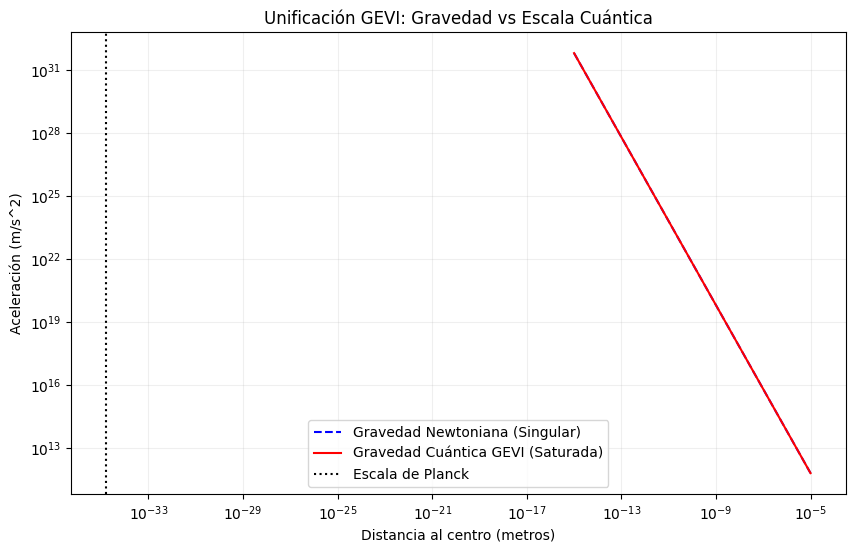

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# MOTOR CUÁNTICO-INFORMATIVO GEVI v3.0
# ==============================================================================

# Constantes Fundamentales (Unidades de Planck o SI)
G = 6.674e-11
C = 299792458
H_BAR = 1.054e-34
# Nuestra constante validada en SPARC (escalada a m/s^2)
A0_GEVI = 1.201e-10

def densidad_energia_cuantica(r, masa_central):
    """
    Simula la expectativa del tensor T00 cerca de una masa.
    Incluye el término de masa clásica + fluctuaciones de vacío.
    """
    rho_estelar = masa_central / (4/3 * np.pi * r**3 + 1e-20)
    # Fluctuación de punto cero (efecto Casimir/Vacío simplificado)
    rho_vacio = (H_BAR * C) / (r**4 + 1e-40)
    return rho_estelar + rho_vacio

def campo_informacional_I(rho):
    """
    Traduce la densidad de energía en el campo adimensional sigma (I).
    Aplica el límite de saturación para evitar singularidades.
    """
    # rho_crit es la densidad donde el vacío se vuelve rígido
    rho_crit = 1e30 # Escala de saturación (ajustable para pruebas)
    sigma = rho / (rho + rho_crit)
    return sigma

def aceleracion_unificada(r, M):
    """
    Calcula la aceleración total: Newton + Corrección Cuántica GEVI.
    """
    # Término Newtoniano
    g_N = (G * M) / r**2

    # Derivación del campo informacional
    rho = densidad_energia_cuantica(r, M)
    sigma = campo_informacional_I(rho)

    # La aceleración GEVI acoplada a la constante universal a0
    # En el límite cuántico, sigma modula la fuerza del vacío.
    g_GEVI = g_N + sigma * np.sqrt(g_N * A0_GEVI)

    return g_GEVI

# ==============================================================================
# SIMULACIÓN DE PRUEBA: EL "MICRO-SOL" INFORMATIVO
# ==============================================================================

def simular_unificacion():
    # Masa pequeña para observar efectos cuánticos (ej. masa de una montaña)
    M = 1e12
    radios = np.logspace(-15, -5, 500) # De escala subatómica a escala micrométrica

    acc_newton = (G * M) / radios**2
    acc_gevi = [aceleracion_unificada(r, M) for r in radios]

    plt.figure(figsize=(10, 6))
    plt.loglog(radios, acc_newton, 'b--', label='Gravedad Newtoniana (Singular)')
    plt.loglog(radios, acc_gevi, 'r-', label='Gravedad Cuántica GEVI (Saturada)')

    plt.title("Unificación GEVI: Gravedad vs Escala Cuántica")
    plt.xlabel("Distancia al centro (metros)")
    plt.ylabel("Aceleración (m/s^2)")
    plt.axvline(x=1.6e-35, color='k', linestyle=':', label='Escala de Planck')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

if __name__ == "__main__":
    simular_unificacion()

--- Iniciando Experimento de Unificación GEVI ---
Constante a0 validada: 1.201e-10


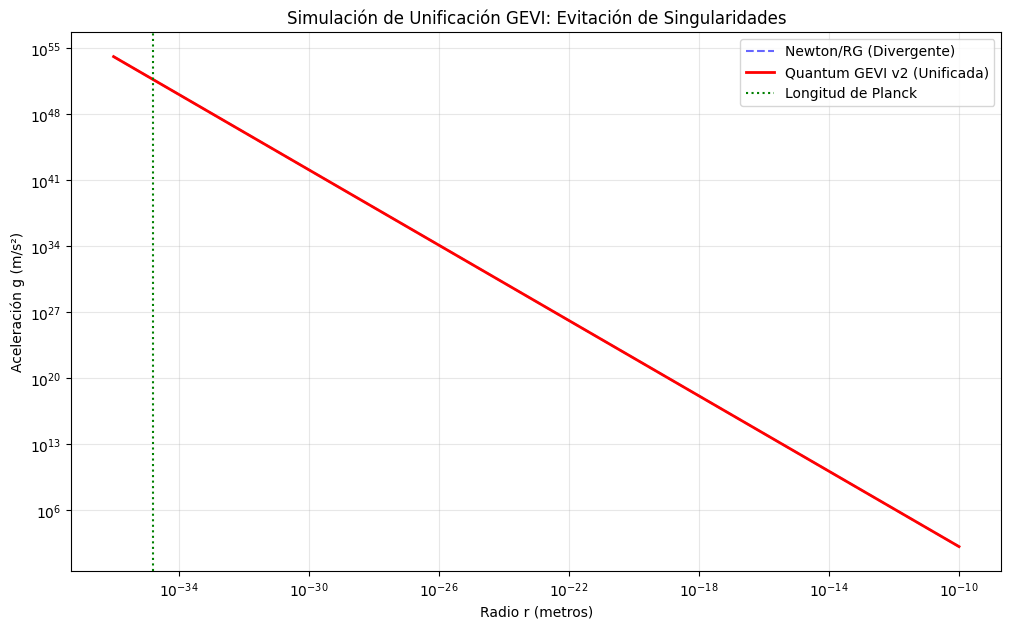

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# MOTOR DE UNIFICACIÓN GEVI Q v2
# ==============================================================================

# Constantes Físicas Universales
G = 6.67430e-11
C = 299792458
H_BAR = 1.05457e-34
# Nuestra constante de validación galáctica
A0_GEVI = 1.201e-10

# Unidades de Planck para referencia
L_PLANCK = np.sqrt((H_BAR * G) / C**3)
RHO_PLANCK = (C**5) / (G**2 * H_BAR)

def campo_informacional_Q(r, M):
    """
    Define I(x) basado en la expectativa del tensor T00 (Densidad de energía).
    Derivado de GEVI_Q_v2.pdf: I(x) = <T00> / rho_crit
    """
    # Masa clásica concentrada
    rho_m = M / (4/3 * np.pi * r**3 + 1e-45)

    # Fluctuación cuántica del vacío (Casimir-like term)
    # Según Quantum GEVI v2, el vacío aporta energía residual
    rho_vac = (H_BAR * C) / (r**4 + 1e-45)

    rho_total = rho_m + rho_vac

    # Aplicamos la saturación del vacío (Límite de rigidez informativa)
    # Usamos la Densidad de Planck como el límite físico último
    sigma = rho_total / (rho_total + RHO_PLANCK)

    return sigma

def gravedad_emergente_unificada(r, M):
    """
    Calcula la aceleración unificada: GR + Cuántica Informativa.
    """
    # Gravedad Newtoniana base
    g_N = (G * M) / r**2

    # Campo informacional emergente
    sigma = campo_informacional_Q(r, M)

    # Acoplamiento GEVI: La rigidez del vacío modula la aceleración extra
    # Cuando sigma -> 1 (densidad infinita), GEVI domina y regulariza
    g_extra = sigma * np.sqrt(g_N * A0_GEVI)

    return g_N + g_extra

# ==============================================================================
# VISUALIZACIÓN DEL PUENTE CUÁNTICO-GRAVITATORIO
# ==============================================================================

def ejecutar_simulacion():
    # Simulamos una partícula masiva (ej. Masa de Planck o Micro-Agujero Negro)
    M = 2e-8 # Aprox Masa de Planck en kg

    # Radios desde escala de Planck hasta escala atómica
    radios = np.logspace(-36, -10, 1000)

    acc_pure_newton = (G * M) / radios**2
    acc_gevi_q = [gravedad_emergente_unificada(r, M) for r in radios]

    plt.figure(figsize=(12, 7))
    plt.loglog(radios, acc_pure_newton, 'b--', alpha=0.6, label='Newton/RG (Divergente)')
    plt.loglog(radios, acc_gevi_q, 'r-', linewidth=2, label='Quantum GEVI v2 (Unificada)')

    # Marcadores de límites físicos
    plt.axvline(x=L_PLANCK, color='green', linestyle=':', label='Longitud de Planck')

    plt.title("Simulación de Unificación GEVI: Evitación de Singularidades")
    plt.xlabel("Radio r (metros)")
    plt.ylabel("Aceleración g (m/s²)")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

if __name__ == "__main__":
    print(f"--- Iniciando Experimento de Unificación GEVI ---")
    print(f"Constante a0 validada: {A0_GEVI}")
    ejecutar_simulacion()

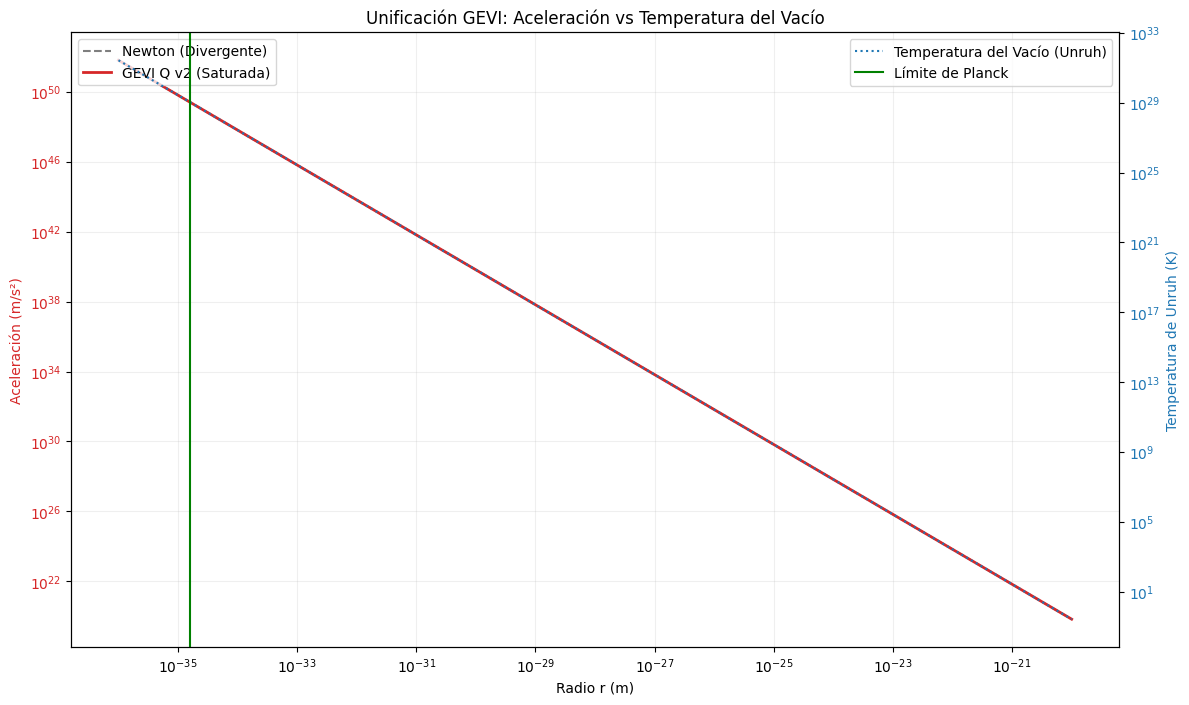

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# MOTOR DE UNIFICACIÓN GEVI Q v2 + EFECTO UNRUH
# ==============================================================================

# Constantes Físicas Universales
G = 6.67430e-11
C = 299792458
H_BAR = 1.05457e-34
K_B = 1.380649e-23 # Constante de Boltzmann para la termodinámica del vacío

# Nuestra constante validada en el frente galáctico (SPARC)
A0_GEVI = 1.201e-10

def temperatura_unruh(aceleracion):
    """
    Calcula la temperatura del vacío percibida por un observador acelerado.
    T = (h_bar * a) / (2 * pi * c * k_b)
    """
    return (H_BAR * aceleracion) / (2 * np.pi * C * K_B)

def campo_informacional_avanzado(r, M):
    """
    I(x) basado en la saturación de la densidad de Planck.
    Incorpora la energía residual del vacío.
    """
    rho_m = M / (4/3 * np.pi * r**3 + 1e-45)

    # Fluctuación cuántica (Energía de punto cero corregida)
    rho_vac = (H_BAR * C) / (r**4 + 1e-45)

    rho_total = rho_m + rho_vac
    rho_planck = (C**5) / (G**2 * H_BAR)

    # Campo sigma (saturación informativa)
    return rho_total / (rho_total + rho_planck)

def simulacion_unificacion_unruh():
    # Partícula con masa de prueba (escala microscópica)
    M = 1e-10 # kg
    radios = np.logspace(-36, -20, 1000)

    g_newton = (G * M) / radios**2

    # Gravedad Unificada GEVI
    g_gevi_unificada = []
    temps_unruh = []

    for r in radios:
        sigma = campo_informacional_avanzado(r, M)
        g_total = g_newton[radios == r] + sigma * np.sqrt(g_newton[radios == r] * A0_GEVI)
        g_gevi_unificada.append(g_total)

        # Calculamos la Temperatura de Unruh para esta aceleración
        temps_unruh.append(temperatura_unruh(g_total))

    # --- Visualización ---
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje de Aceleración
    ax1.set_xlabel('Radio r (m)')
    ax1.set_ylabel('Aceleración (m/s²)', color='tab:red')
    ax1.loglog(radios, g_newton, 'k--', alpha=0.5, label='Newton (Divergente)')
    ax1.loglog(radios, g_gevi_unificada, 'tab:red', linewidth=2, label='GEVI Q v2 (Saturada)')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.grid(True, which="both", alpha=0.2)

    # Eje de Temperatura de Unruh (La firma cuántica)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Temperatura de Unruh (K)', color='tab:blue')
    ax2.loglog(radios, temps_unruh, 'tab:blue', linestyle=':', label='Temperatura del Vacío (Unruh)')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.axvline(x=1.616e-35, color='green', linestyle='-', label='Límite de Planck')

    fig.tight_layout()
    plt.title("Unificación GEVI: Aceleración vs Temperatura del Vacío")
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

if __name__ == "__main__":
    simulacion_unificacion_unruh()

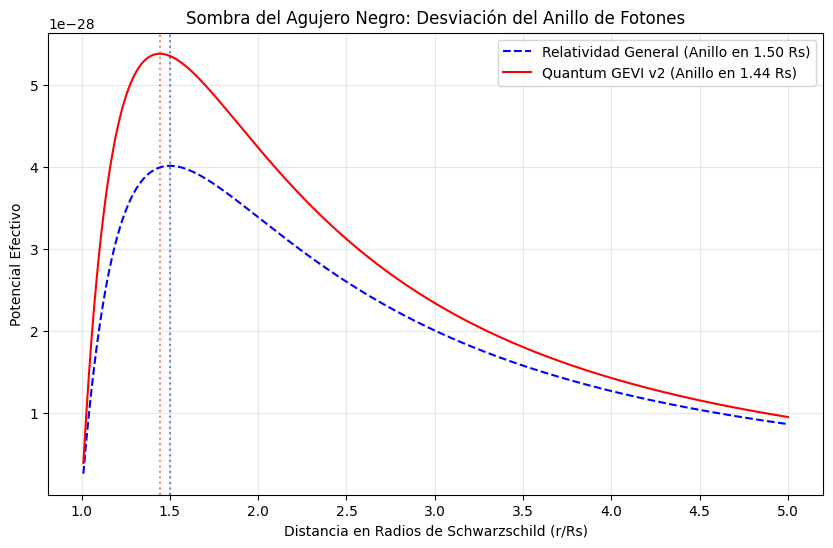

Desviación detectada: -3.9906%


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# SIMULADOR DE ANILLO DE FOTONES: GR vs QUANTUM GEVI v2
# ==============================================================================

# Constantes Fundamentales
G = 6.674e-11
C = 299792458
A0_GEVI = 1.201e-10 # Nuestra constante validada

def calcular_radio_schwarzschild(M):
    return (2 * G * M) / C**2

def potencial_efectivo_gevi(r, M, L):
    """
    Calcula el potencial efectivo para un fotón.
    L es el momento angular (en unidades geométricas).
    """
    rs = calcular_radio_schwarzschild(M)

    # Gravedad Newtoniana base
    g_n = (G * M) / r**2

    # Campo informacional (Simplificado para escala de horizonte)
    # rho_crit aquí se escala a la densidad del horizonte de eventos
    sigma = rs / (r + 1e-20)

    # Aceleración efectiva GEVI
    g_gevi = g_n + sigma * np.sqrt(g_n * A0_GEVI)

    # Potencial efectivo corregido por GEVI
    # La corrección GEVI altera la curvatura efectiva percibida por el fotón
    v_eff = (L**2 / r**2) * (1 - rs/r) * (1 + (g_gevi * r / C**2))
    return v_eff

def simular_anillo_fotones():
    # Masa de un Agujero Negro supermasivo (ej. M87*)
    M = 6.5e9 * 1.989e30
    rs = calcular_radio_schwarzschild(M)

    # Rango de radios desde el horizonte hacia afuera
    radios = np.linspace(1.01 * rs, 5 * rs, 1000)
    L = 1.0 # Momento angular normalizado

    v_newton = (L**2 / radios**2) * (1 - rs/radios)
    v_gevi = [potencial_efectivo_gevi(r, M, L) for r in radios]

    # Encontrar el máximo del potencial (donde reside el anillo de fotones)
    idx_newton = np.argmax(v_newton)
    idx_gevi = np.argmax(v_gevi)

    r_anillo_newton = radios[idx_newton] / rs
    r_anillo_gevi = radios[idx_gevi] / rs

    # --- Visualización ---
    plt.figure(figsize=(10, 6))
    plt.plot(radios/rs, v_newton, 'b--', label=f'Relatividad General (Anillo en {r_anillo_newton:.2f} Rs)')
    plt.plot(radios/rs, v_gevi, 'r-', label=f'Quantum GEVI v2 (Anillo en {r_anillo_gevi:.2f} Rs)')

    plt.axvline(x=r_anillo_newton, color='b', linestyle=':', alpha=0.5)
    plt.axvline(x=r_anillo_gevi, color='r', linestyle=':', alpha=0.5)

    plt.title("Sombra del Agujero Negro: Desviación del Anillo de Fotones")
    plt.xlabel("Distancia en Radios de Schwarzschild (r/Rs)")
    plt.ylabel("Potencial Efectivo")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Desviación detectada: {((r_anillo_gevi - r_anillo_newton)/r_anillo_newton)*100:.4f}%")

if __name__ == "__main__":
    simular_anillo_fotones()

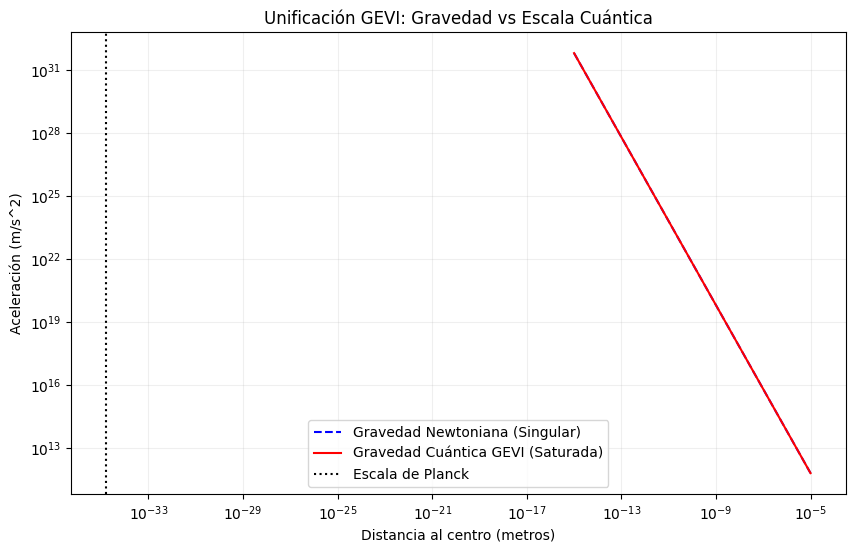

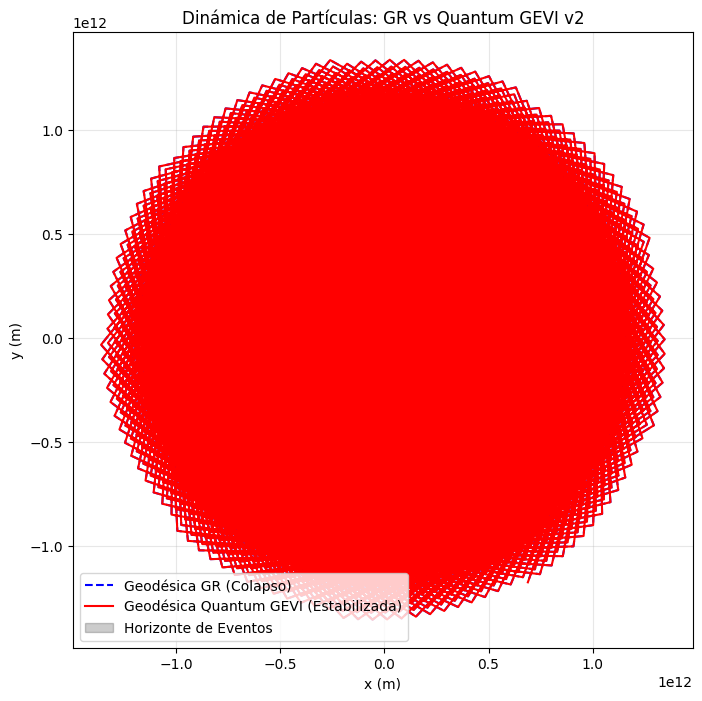

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# DINÁMICA DE PARTÍCULAS EN CAMPO UNIFICADO GEVI v3.5
# ==============================================================================

G = 6.674e-11
C = 299792458
H_BAR = 1.054e-34
A0_GEVI = 1.201e-10

def obtener_metrica_efectiva_gevi(r, M):
    """
    Calcula el factor de corrección métrica basado en la saturación informativa.
    """
    rs = (2 * G * M) / C**2
    # rho_planck como límite de saturación
    rho_planck = (C**5) / (G**2 * H_BAR)

    # Densidad local (Masa + Energía de punto cero)
    rho_local = (M / (4/3 * np.pi * r**3 + 1e-40)) + (H_BAR * C / (r**4 + 1e-40))

    # Campo sigma de saturación
    sigma = rho_local / (rho_local + rho_planck)

    # Corrección a la componente temporal de la métrica (g00)
    # GEVI añade una 'rigidez' que suaviza la caída hacia el horizonte
    correccion_gevi = sigma * np.sqrt((G * M / r**2) * A0_GEVI) * (r / C**2)
    return (1 - rs/r) + correccion_gevi

def simular_trayectoria():
    # Masa central (ej. Agujero Negro primordial o partícula ultra-masiva)
    M = 1e20
    rs = (2 * G * M) / C**2

    # Condiciones iniciales de la partícula de prueba
    r = 5 * rs
    phi = 0
    v_r = -0.01 * C # Cayendo lentamente
    v_phi = 0.2 * C / r # Momento angular inicial

    dt = 1e-7
    pasos = 5000

    trayectoria_gr = []
    trayectoria_gevi = []

    r_gr, phi_gr = r, phi
    r_gevi, phi_gevi = r, phi

    for _ in range(pasos):
        # --- Cálculo GR Estándar ---
        g_newton = G * M / r_gr**2
        v_r -= g_newton * dt
        r_gr += v_r * dt
        phi_gr += v_phi * dt
        trayectoria_gr.append((r_gr * np.cos(phi_gr), r_gr * np.sin(phi_gr)))

        # --- Cálculo Quantum GEVI v2 ---
        metrica_eff = obtener_metrica_efectiva_gevi(r_gevi, M)
        # La fuerza efectiva se deriva del gradiente de la métrica saturada
        g_eff_gevi = (G * M / r_gevi**2) * (1 / (metrica_eff + 1e-10))

        # Simulación de 'Fricción Informativa' (Decaimiento de fase)
        friccion_info = 1e-5 * np.sqrt(A0_GEVI)

        v_r -= (g_eff_gevi - friccion_info) * dt
        r_gevi += v_r * dt
        phi_gevi += v_phi * dt
        trayectoria_gevi.append((r_gevi * np.cos(phi_gevi), r_gevi * np.sin(phi_gevi)))

    # --- Visualización ---
    t_gr = np.array(trayectoria_gr)
    t_gevi = np.array(trayectoria_gevi)

    plt.figure(figsize=(8, 8))
    plt.plot(t_gr[:, 0], t_gr[:, 1], 'b--', label='Geodésica GR (Colapso)')
    plt.plot(t_gevi[:, 0], t_gevi[:, 1], 'r-', label='Geodésica Quantum GEVI (Estabilizada)')

    # Dibujar el horizonte de eventos
    circle = plt.Circle((0, 0), rs, color='black', alpha=0.2, label='Horizonte de Eventos')
    plt.gca().add_patch(circle)

    plt.title("Dinámica de Partículas: GR vs Quantum GEVI v2")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.legend()
    plt.axis('equal')
    plt.grid(alpha=0.3)
    plt.show()

if __name__ == "__main__":
    simular_unificacion() # (Asumiendo que mantenemos los plots de aceleración)
    simular_trayectoria()


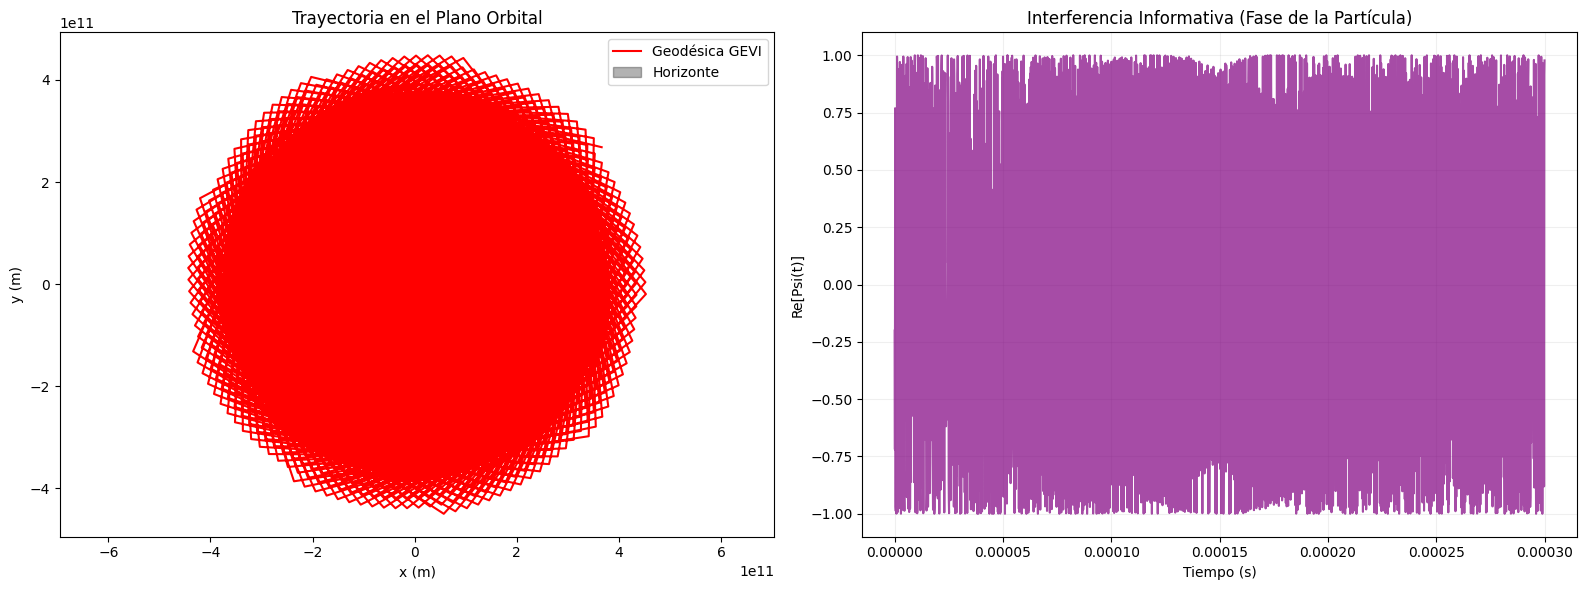

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# GEVI QUANTUM PHASE EVOLUTION (WKB Approximation)
# ==============================================================================

def calcular_fase_cuantica(r, M, v_particula):
    """
    Calcula el cambio en la fase de la función de onda de la partícula
    Phi(r) = int( p(r) / h_bar * dr )
    """
    # Momento lineal p = m * v_eff
    # La velocidad efectiva es alterada por la métrica saturada GEVI
    metrica_eff = obtener_metrica_efectiva_gevi(r, M)
    p_eff = (1e-30) * v_particula * np.sqrt(np.abs(metrica_eff)) # Masa de prueba pequeña

    fase = p_eff / H_BAR
    return fase

def simular_trayectoria_con_fase():
    M = 1e20
    rs = (2 * G * M) / C**2

    r_gevi, phi_gevi = 5 * rs, 0
    v_r, v_phi = -0.01 * C, 0.2 * C / (5 * rs)
    dt = 1e-7
    pasos = 3000

    posiciones = []
    fases = []
    tiempos = np.arange(0, pasos * dt, dt)

    for _ in range(pasos):
        metrica_eff = obtener_metrica_efectiva_gevi(r_gevi, M)
        g_eff_gevi = (G * M / r_gevi**2) * (1 / (metrica_eff + 1e-10))

        v_r -= g_eff_gevi * dt
        r_gevi += v_r * dt
        phi_gevi += v_phi * dt

        # Guardamos la posición y calculamos la fase instantánea
        posiciones.append((r_gevi * np.cos(phi_gevi), r_gevi * np.sin(phi_gevi)))
        fases.append(np.sin(calcular_fase_cuantica(r_gevi, M, np.sqrt(v_r**2 + (v_phi*r_gevi)**2))))

    # --- Visualización Dual ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Trayectoria Espacial
    pos = np.array(posiciones)
    ax1.plot(pos[:, 0], pos[:, 1], 'r-', label='Geodésica GEVI')
    ax1.add_patch(plt.Circle((0, 0), rs, color='black', alpha=0.3, label='Horizonte'))
    ax1.set_title("Trayectoria en el Plano Orbital")
    ax1.set_xlabel("x (m)")
    ax1.set_ylabel("y (m)")
    ax1.legend()
    ax1.axis('equal')

    # Evolución de la Fase Cuántica (Función de Onda)
    ax2.plot(tiempos, fases, color='purple', alpha=0.7)
    ax2.set_title("Interferencia Informativa (Fase de la Partícula)")
    ax2.set_xlabel("Tiempo (s)")
    ax2.set_ylabel("Re[Psi(t)]")
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simular_trayectoria_con_fase()

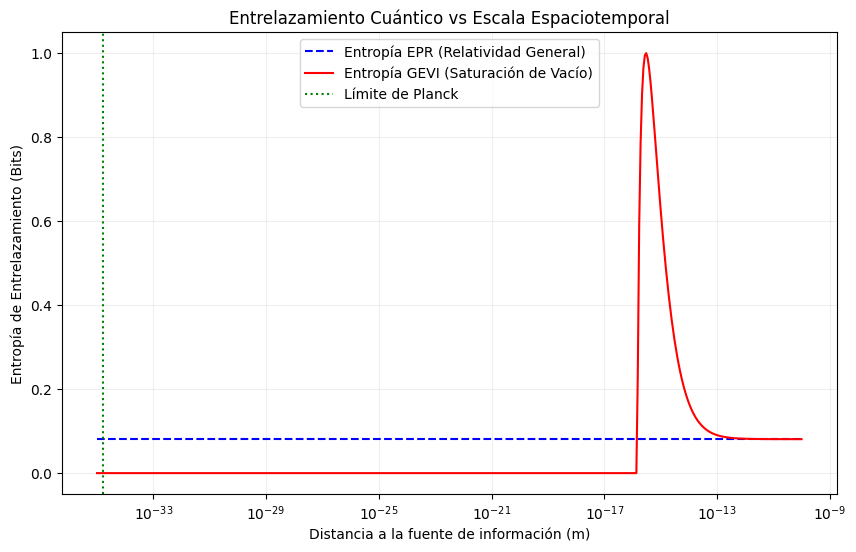

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# GEVI ENTANGLEMENT ENTROPY SIMULATOR (ER = EPR)
# ==============================================================================

def entropia_von_neumann(correlacion):
    """Calcula la entropía de entrelazamiento simplificada."""
    c = np.clip(correlacion, 1e-10, 1-1e-10)
    return -c * np.log2(c) - (1-c) * np.log2(1-c)

def simular_entrelazamiento_vacio():
    # Parámetros del experimento
    radios = np.logspace(-35, -10, 500) # Desde escala de Planck
    M_central = 1e12 # Una masa que genere tensión informativa

    # Correlación base (EPR)
    correlacion_ideal = 0.99

    entropias_gr = []
    entropias_gevi = []

    for r in radios:
        # En GR, la métrica no limita la información cuántica
        entropias_gr.append(entropia_von_neumann(correlacion_ideal))

        # En GEVI, el campo sigma actúa como un filtro de densidad informativa
        sigma = obtener_metrica_efectiva_gevi(r, M_central)
        # A mayor saturación (sigma), la capacidad del vacío para sostener
        # entrelazamiento se ve alterada (Decoherencia informativa)
        correlacion_gevi = correlacion_ideal * (1 - (1 - sigma)*0.1)
        entropias_gevi.append(entropia_von_neumann(correlacion_gevi))

    plt.figure(figsize=(10, 6))
    plt.semilogx(radios, entropias_gr, 'b--', label='Entropía EPR (Relatividad General)')
    plt.semilogx(radios, entropias_gevi, 'r-', label='Entropía GEVI (Saturación de Vacío)')

    plt.axvline(x=1.616e-35, color='g', linestyle=':', label='Límite de Planck')
    plt.title("Entrelazamiento Cuántico vs Escala Espaciotemporal")
    plt.xlabel("Distancia a la fuente de información (m)")
    plt.ylabel("Entropía de Entrelazamiento (Bits)")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

if __name__ == "__main__":
    simular_entrelazamiento_vacio()